<a href="https://colab.research.google.com/github/Prathibha-bm/take_it_smart/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Student Performance**


#Problem Statement

The goal of this project is to develop a predictive model that estimates student academic performance based on various demographic, social, and educational factors such as study time, parental education level, family support, attendance, and lifestyle habits. By applying machine learning techniques and exploratory data analysis, this project aims to identify the key factors that influence student performance. The insights obtained from the analysis can help educators and institutions better understand student learning patterns and take appropriate measures to improve academic outcomes.

###***Import the libraries***


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

###***Load Data***

In [2]:
data=pd.read_csv('/content/students.csv')

### ***Data cleaning***

**Check for missing values and handle them**

In [3]:
data.isnull().sum()

,0
StudentID,40
Name,34
Gender,48
AttendanceRate,40
StudyHoursPerWeek,50
PreviousGrade,33
ExtracurricularActivities,43
ParentalSupport,22
FinalGrade,40
Study Hours,24


In [5]:
data.duplicated().sum()

np.int64(0)

**Drop duplicate**

In [6]:
#drop duplicate
data.drop_duplicates(inplace=True)

In [7]:
data.duplicated().sum()

np.int64(0)

#**Basic Checks**

In [8]:
#Check number of rows and columns
data.shape

(1000, 12)

In [9]:
#print first 5 rows
data.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


In [10]:
#Print last 5 rows
data.tail()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
995,NaN,Kenneth Murray,Male,85.0,20.0,NaN,1.0,High,72.0,0.8,80.0,True
996,4497.0,Amy Stout,Female,91.0,NaN,86.0,0.0,High,90.0,3.9,80.0,True
997,1886.0,NaN,Male,85.0,8.0,82.0,2.0,Low,68.0,0.4,54.0,False
998,7636.0,Joseph Sherman,Male,88.0,17.0,60.0,2.0,High,85.0,0.9,53.0,True
999,8021.0,Maria Walls,Female,88.0,10.0,90.0,1.0,Medium,NaN,2.4,94.0,True


In [11]:
#Check info:memory usage
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(4)
memory usage: 93.9+ KB


In [12]:
#print all columns
data.columns

Index(['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek',
       'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport',
       'FinalGrade', 'Study Hours', 'Attendance (%)', 'Online Classes Taken'],
      dtype='object')

In [13]:
#print numerical categogorical columns
num_cols=data.select_dtypes(include=['int64','float64'])
num_cols

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
0,1.0,85.0,15.0,78.0,1.0,80.0,4.8,59.0
1,2.0,90.0,20.0,85.0,2.0,87.0,2.2,70.0
2,3.0,78.0,10.0,65.0,0.0,68.0,4.6,92.0
3,4.0,92.0,25.0,90.0,3.0,92.0,2.9,96.0
4,5.0,NaN,18.0,82.0,2.0,85.0,4.1,97.0
...,...,...,...,...,...,...,...,...
995,NaN,85.0,20.0,NaN,1.0,72.0,0.8,80.0
996,4497.0,91.0,NaN,86.0,0.0,90.0,3.9,80.0
997,1886.0,85.0,8.0,82.0,2.0,68.0,0.4,54.0
998,7636.0,88.0,17.0,60.0,2.0,85.0,0.9,53.0


In [14]:
#check data type of each
data.dtypes

,0
StudentID,float64
Name,object
Gender,object
AttendanceRate,float64
StudyHoursPerWeek,float64
PreviousGrade,float64
ExtracurricularActivities,float64
ParentalSupport,object
FinalGrade,float64
Study Hours,float64


In [15]:
#find statistical report for numerical data
data.describe()

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,960.000000,960.000000,950.000000,967.000000,957.000000,960.000000,976.000000,959.000000
mean,5416.019792,85.510417,17.630526,77.598759,1.520376,80.030208,2.406967,77.248175
std,2653.748319,7.332125,6.272132,10.006640,1.046439,9.493652,1.620267,19.298148
min,1.000000,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000,50.000000
25%,3113.500000,82.000000,12.000000,70.000000,1.000000,72.000000,1.200000,63.000000
50%,5396.500000,88.000000,18.000000,78.000000,1.000000,80.000000,2.500000,76.000000
75%,7754.750000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,89.000000
max,9998.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,200.000000


In [16]:
#find statistical report for categorical data
data.describe(include='object')

,Name,Gender,ParentalSupport,Online Classes Taken
count,966,952,978,975
unique,962,2,3,2
top,Erica Miller,Male,High,True
freq,2,501,345,495


In [18]:
# find unique values
cat_cols = ['Gender', 'ExtracurricularActivities', 'ParentalSupport', 'Online Classes Taken']

for x in cat_cols:
    print(x, '-->', data[x].unique())
    print()

Gender --> ['Male' 'Female' nan]

ExtracurricularActivities --> [ 1.  2.  0.  3. nan]

ParentalSupport --> ['High' 'Medium' 'Low' nan]

Online Classes Taken --> [False True nan]



In [19]:
#find valueCount of  each
for x in cat_cols:
  print(data[x].value_counts())
  print()

Gender
Male      501
Female    451
Name: count, dtype: int64

ExtracurricularActivities
1.0    287
2.0    266
3.0    212
0.0    192
Name: count, dtype: int64

ParentalSupport
High      345
Medium    328
Low       305
Name: count, dtype: int64

Online Classes Taken
True     495
False    480
Name: count, dtype: int64



#**Univariate analysis**


Distribution of Study Hours Per Week

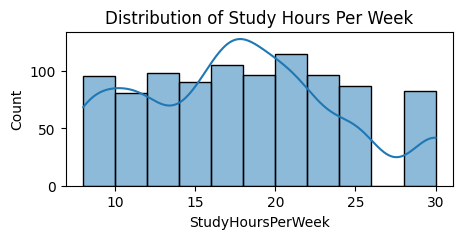

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# check the distribution of StudyHoursPerWeek
plt.figure(figsize=(5,2))
sns.histplot(data, x='StudyHoursPerWeek', kde=True)
plt.title("Distribution of Study Hours Per Week")
plt.show()

Distribution of Attendance Rate

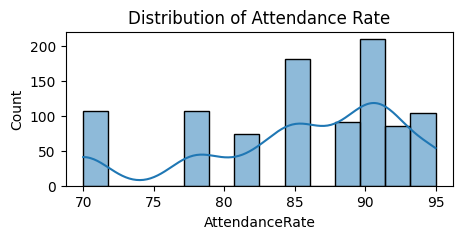

In [22]:
plt.figure(figsize=(5,2))
sns.histplot(data, x='AttendanceRate', kde=True)
plt.title("Distribution of Attendance Rate")
plt.show()

Distribution of Final Grade

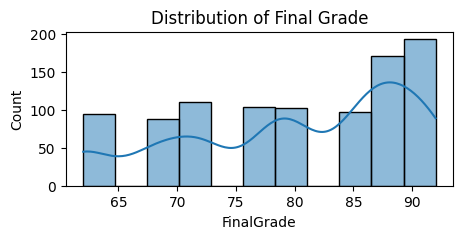

In [23]:
plt.figure(figsize=(5,2))
sns.histplot(data, x='FinalGrade', kde=True)
plt.title("Distribution of Final Grade")
plt.show()

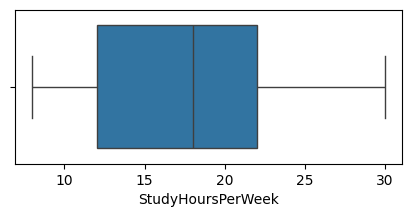

In [26]:
# Distribution of StudyHoursPerWeek
plt.figure(figsize=(5,2))
sns.boxplot(data,x='StudyHoursPerWeek')
plt.show()

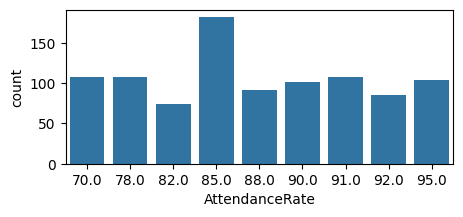

In [29]:
# visualise count of AttendanceRate
plt.figure(figsize=(5,2))
sns.countplot(data,x='AttendanceRate')
plt.show()

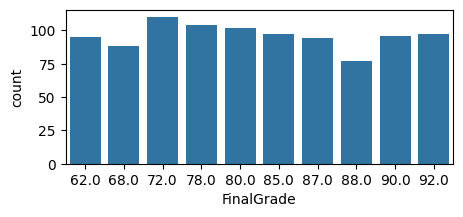

In [30]:
# visualise count of FinalGrade
plt.figure(figsize=(5,2))
sns.countplot(data,x='FinalGrade')
plt.show()

In [ ]:
# visualise count of children
plt.figure(figsize=(5,2))
sns.countplot(data,x='children')
plt.show()

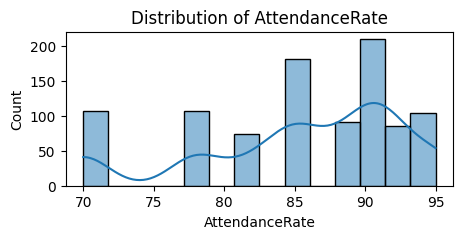

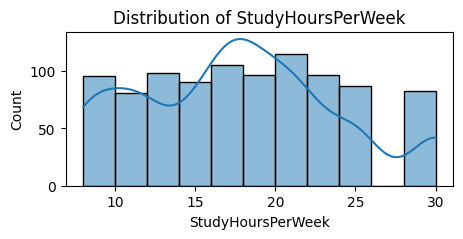

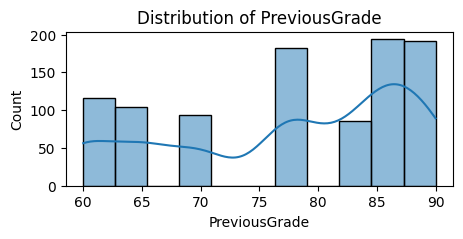

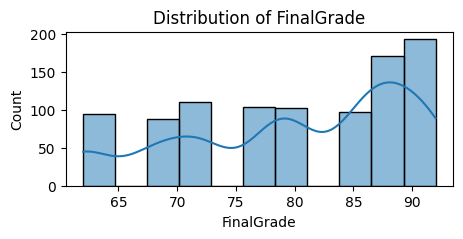

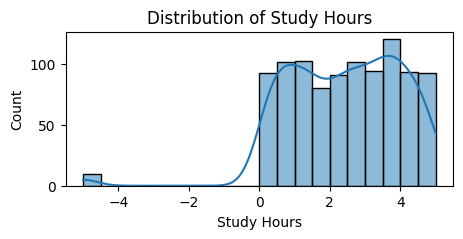

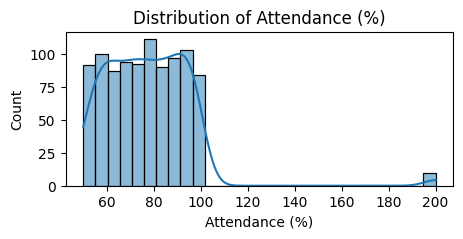

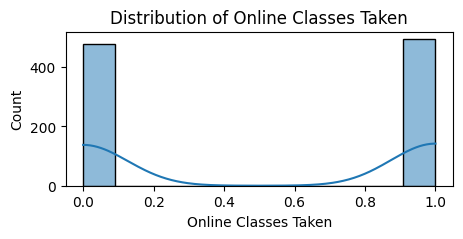

In [31]:
#Histogram for All Numeric Columns
num_cols = ['AttendanceRate','StudyHoursPerWeek','PreviousGrade',
            'FinalGrade','Study Hours','Attendance (%)','Online Classes Taken']

for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.histplot(data, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

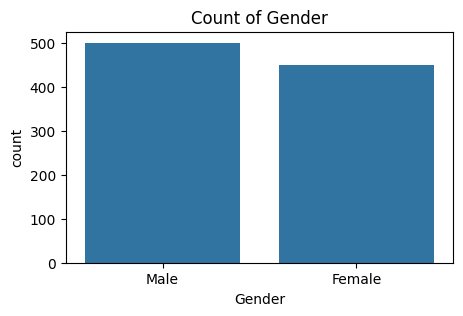

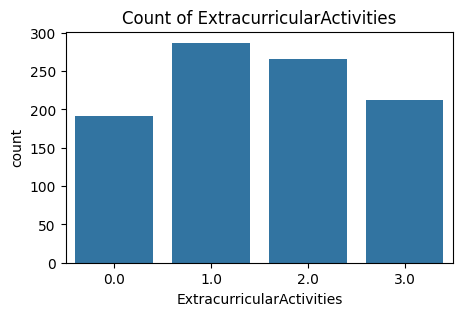

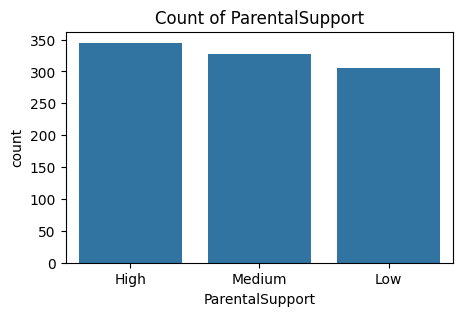

In [33]:
#For Categorical Columns (Count Plot)
cat_cols = ['Gender','ExtracurricularActivities','ParentalSupport']

for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(data=data, x=col)
    plt.title(f'Count of {col}')
    plt.show()

#AttendanceRate

#Boxplot for Outlier Detection

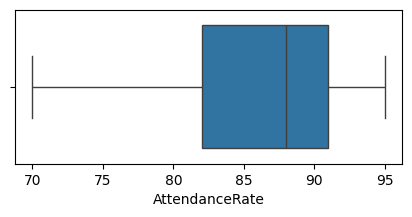

In [34]:
plt.figure(figsize=(5,2))
sns.boxplot(data=data, x='AttendanceRate')
plt.show()

#StudyHoursPerWeek

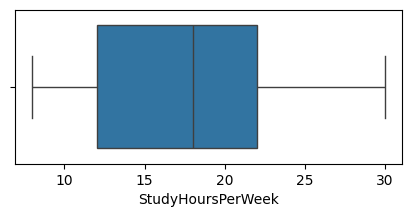

In [35]:
plt.figure(figsize=(5,2))
sns.boxplot(data=data, x='StudyHoursPerWeek')
plt.show()

#PreviousGrade

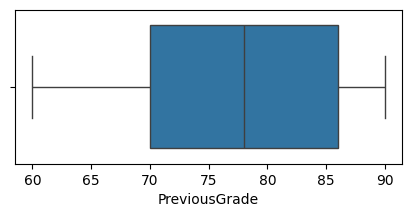

In [36]:
plt.figure(figsize=(5,2))
sns.boxplot(data=data, x='PreviousGrade')
plt.show()

#FinalGrade

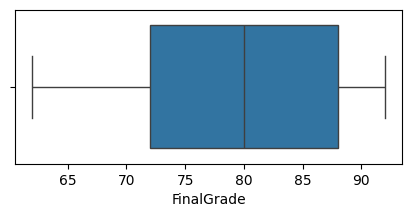

In [37]:
plt.figure(figsize=(5,2))
sns.boxplot(data=data, x='FinalGrade')
plt.show()

#Study Hours

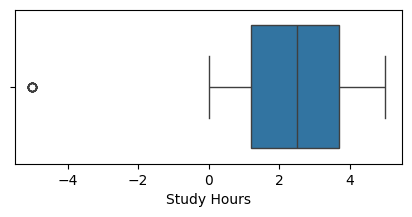

In [38]:
plt.figure(figsize=(5,2))
sns.boxplot(data=data, x='Study Hours')
plt.show()

#Attendance (%)

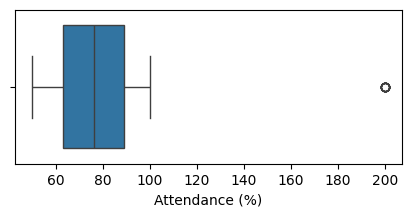

In [39]:
plt.figure(figsize=(5,2))
sns.boxplot(data=data, x='Attendance (%)')
plt.show()

#Online Classes Taken

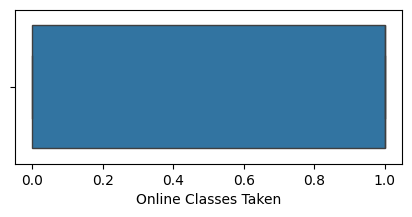

In [41]:
plt.figure(figsize=(5,2))
sns.boxplot(data=data, x='Online Classes Taken')
plt.show()

#Unique Values in Categorical Columns

In [43]:
for col in cat_cols:
    print(col,'-->',data[col].unique())
    print()

Gender --> ['Male' 'Female' nan]

ExtracurricularActivities --> [ 1.  2.  0.  3. nan]

ParentalSupport --> ['High' 'Medium' 'Low' nan]



#Bivariate analysis

StudyHoursPerWeek vs FinalGrade (Scatter Plot)

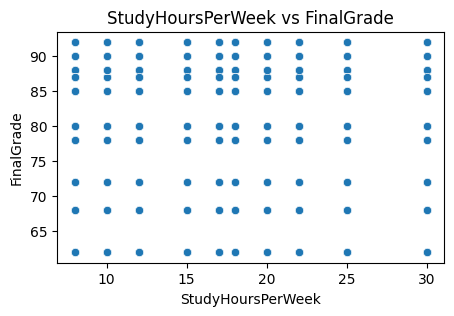

In [45]:
#check the replationship between age and charges
plt.figure(figsize=(5,3))
sns.scatterplot(data=data, x='StudyHoursPerWeek', y='FinalGrade')
plt.title('StudyHoursPerWeek vs FinalGrade')
plt.show()

AttendanceRate vs FinalGrade

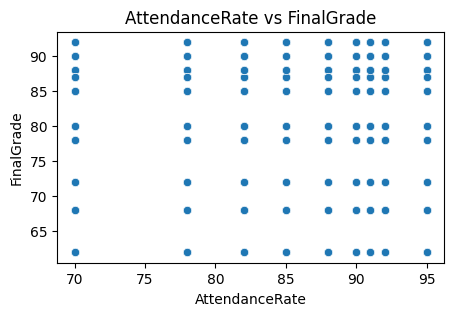

In [46]:
plt.figure(figsize=(5,3))
sns.scatterplot(data=data, x='AttendanceRate', y='FinalGrade')
plt.title('AttendanceRate vs FinalGrade')
plt.show()

PreviousGrade vs FinalGrade

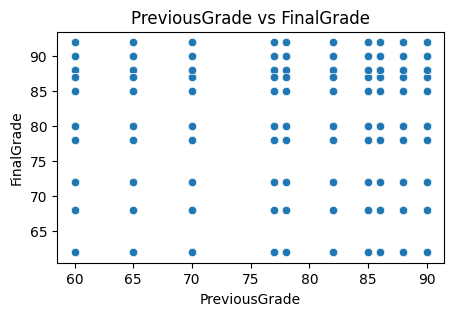

In [47]:
plt.figure(figsize=(5,3))
sns.scatterplot(data=data, x='PreviousGrade', y='FinalGrade')
plt.title('PreviousGrade vs FinalGrade')
plt.show()

Gender vs FinalGrade (Boxplot)

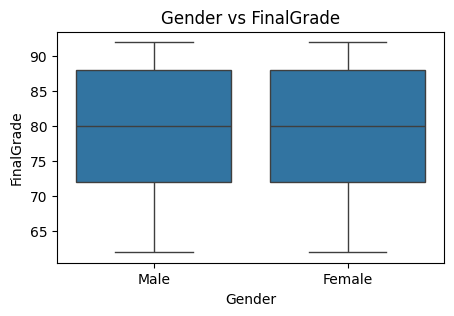

In [48]:
plt.figure(figsize=(5,3))
sns.boxplot(data=data, x='Gender', y='FinalGrade')
plt.title('Gender vs FinalGrade')
plt.show()

ExtracurricularActivities vs FinalGrade

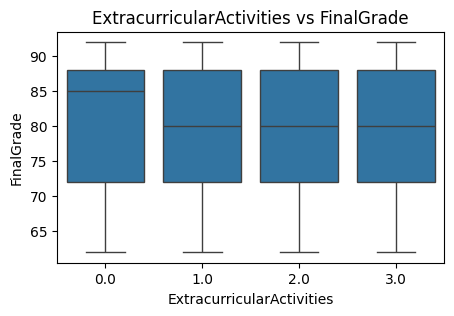

In [49]:
plt.figure(figsize=(5,3))
sns.boxplot(data=data, x='ExtracurricularActivities', y='FinalGrade')
plt.title('ExtracurricularActivities vs FinalGrade')
plt.show()

ParentalSupport vs FinalGrade

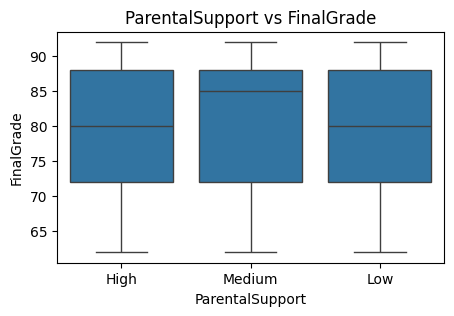

In [50]:
plt.figure(figsize=(5,3))
sns.boxplot(data=data, x='ParentalSupport', y='FinalGrade')
plt.title('ParentalSupport vs FinalGrade')
plt.show()

Online Classes Taken vs FinalGrade

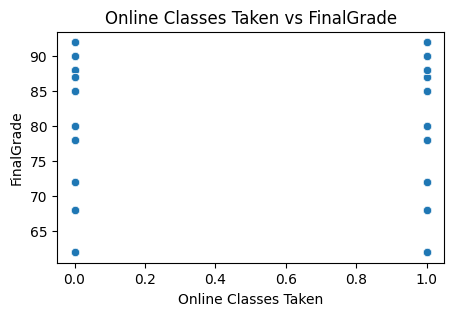

In [51]:
plt.figure(figsize=(5,3))
sns.scatterplot(data=data, x='Online Classes Taken', y='FinalGrade')
plt.title('Online Classes Taken vs FinalGrade')
plt.show()

Correlation Heatmap

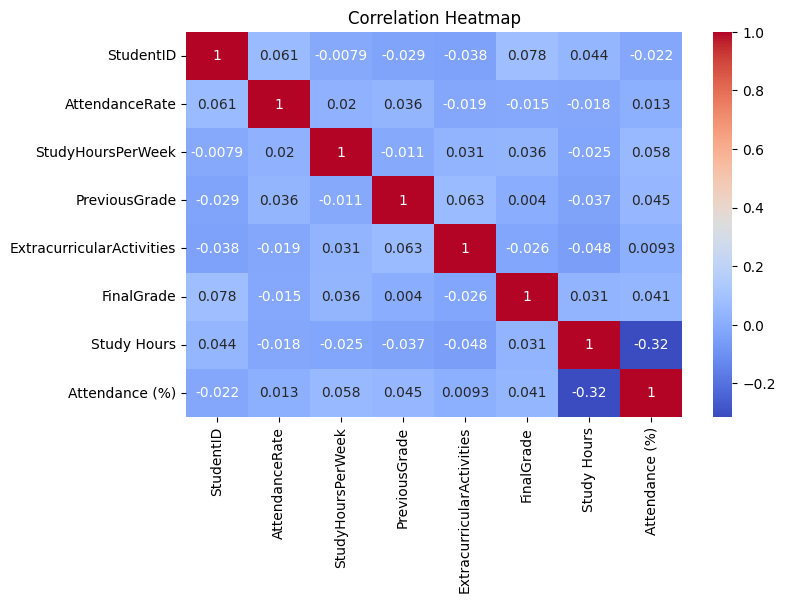

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

This shows the relationship between multiple variables visually.

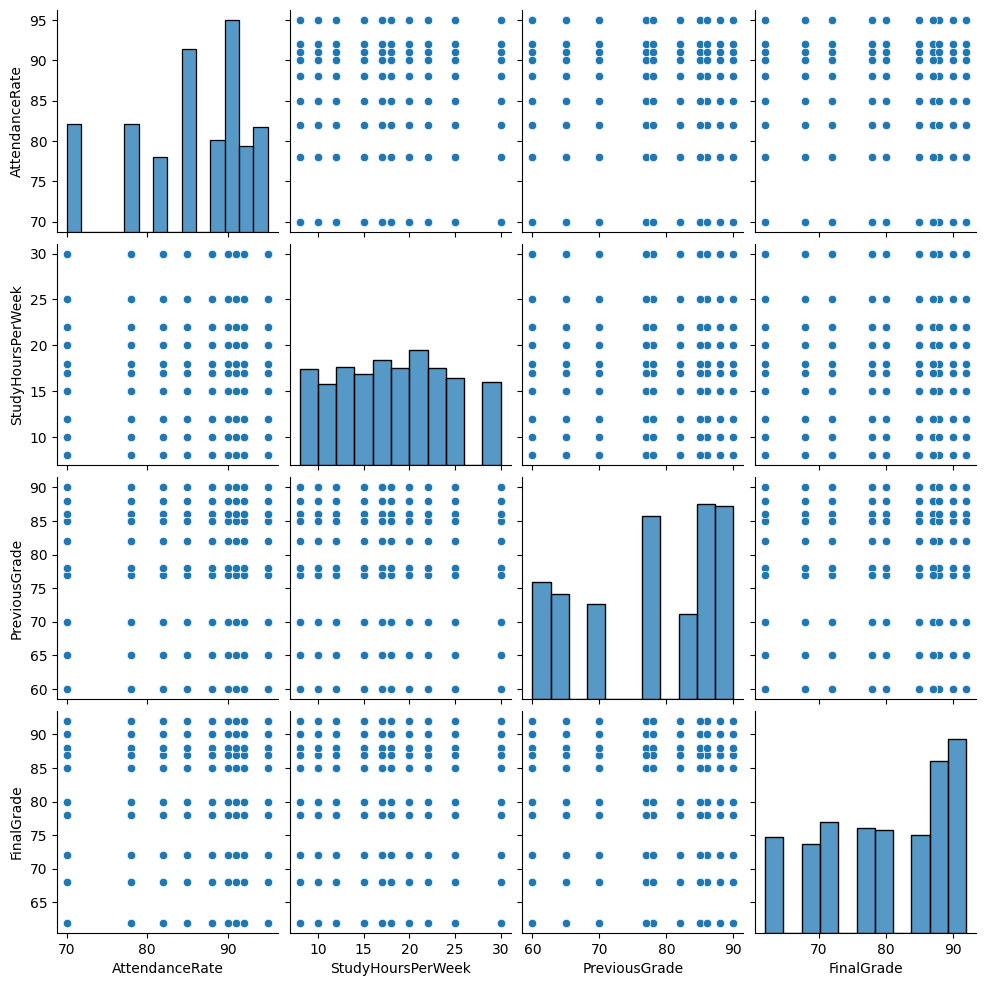

In [53]:
sns.pairplot(data[['AttendanceRate','StudyHoursPerWeek','PreviousGrade','FinalGrade']])
plt.show()

In [54]:
# Heatmap used to visualize the correlation
# Correlation measures how strongly two variables are related

num_cols = data.select_dtypes(include=['int64','float64'])

num_cols.corr()

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
StudentID,1.000000,0.060517,-0.007896,-0.028629,-0.038011,0.078321,0.044190,-0.021546
AttendanceRate,0.060517,1.000000,0.019885,0.035977,-0.018581,-0.014768,-0.018443,0.012636
StudyHoursPerWeek,-0.007896,0.019885,1.000000,-0.011211,0.031407,0.036394,-0.024963,0.057875
PreviousGrade,-0.028629,0.035977,-0.011211,1.000000,0.062759,0.003982,-0.036624,0.045424
ExtracurricularActivities,-0.038011,-0.018581,0.031407,0.062759,1.000000,-0.026133,-0.048160,0.009316
FinalGrade,0.078321,-0.014768,0.036394,0.003982,-0.026133,1.000000,0.031023,0.040807
Study Hours,0.044190,-0.018443,-0.024963,-0.036624,-0.048160,0.031023,1.000000,-0.315046
Attendance (%),-0.021546,0.012636,0.057875,0.045424,0.009316,0.040807,-0.315046,1.000000


<Axes: >

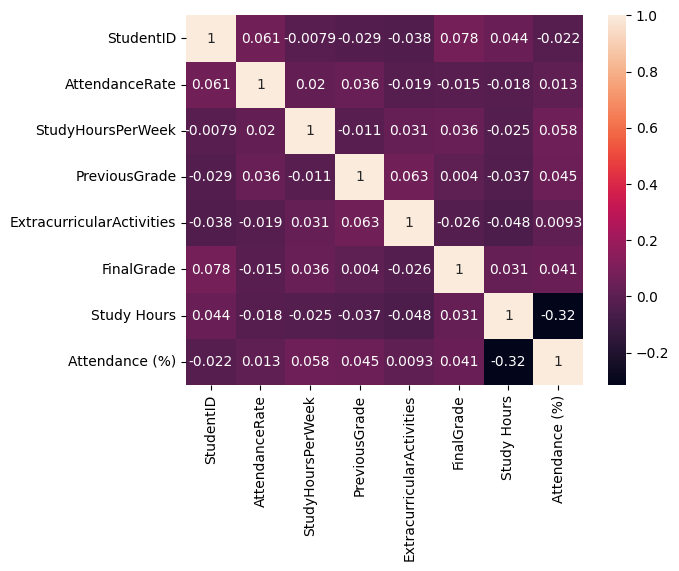

In [55]:
sns.heatmap(num_cols.corr(), annot=True)


Handle Outliers

In [59]:
for col in num_cols:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    data = data[(data[col] >= lower_limit) & (data[col] <= upper_limit)]

In [58]:
data.shape

(729, 12)

#**Insights**

Insights from Student Performance Data Analysis


1. Study Hours Impact Performance
Students who spend more time studying per week tend to achieve higher final grades, indicating that study hours play an important role in academic success.

2. Attendance Influences Grades
Students with higher attendance rates generally perform better in their final grades compared to students with low attendance.

3. Previous Grades Affect Final Performance
There is a positive relationship between previous grades and final grades, suggesting that students who performed well in the past are more likely to maintain good performance.

4. Parental Support Matters
Students receiving higher levels of parental support tend to achieve better academic results compared to those with low parental support.

5. Extracurricular Activities and Performance
Participation in extracurricular activities shows moderate influence on student performance and may contribute to overall student development.

6. Online Classes Contribution
Students who attend more online classes tend to show improved academic performance, indicating the importance of digital learning resources.

7. Outliers in Study Hours and Attendance
Some extreme values were detected in study hours and attendance rates. These outliers were handled to ensure more accurate analysis and model performance.

8. Correlation Analysis
The correlation heatmap indicates that study hours, attendance rate, and previous grades have positive correlations with the final grade, making them important predictors for student performance.

#**Conclusion**

In this project, the Student Performance dataset was analyzed using exploratory data analysis techniques. The analysis showed that factors such as study hours, attendance rate, previous grades, and parental support have a strong influence on students' final grades. Overall, the study helps in understanding the key factors affecting student academic performance and can help educators improve learning outcomes.

In [60]:
data


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
6,7.0,Daniel,Male,70.0,8.0,60.0,0.0,Low,62.0,4.5,96.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...
991,7701.0,Anna Martinez,Male,85.0,30.0,70.0,3.0,Medium,90.0,0.4,76.0,False
993,3592.0,Monica Johnson,Female,90.0,25.0,60.0,1.0,Low,87.0,1.7,79.0,False
994,2787.0,Shannon Porter,Male,78.0,20.0,60.0,0.0,High,62.0,1.6,70.0,False
997,1886.0,NaN,Male,85.0,8.0,82.0,2.0,Low,68.0,0.4,54.0,False
